# Norwegian reservoir filling data

This notebook is the analysis and documentation workspace for the IND320 reservoir project. It loads the local `reservoirs.csv` file, gives its fields readable English names, and uses Seaborn to examine how numeric measurements change over time. The companion Streamlit app uses numeric fill-level values from the same CSV to show weekly area series.

In [1]:
# Import packages for the time-series plots below.

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load the source data and replace abbreviated Norwegian headers.
df = pd.read_csv("reservoirs.csv")
df.columns = [
    "Observation Date",
    "Area Type",
    "Area Code",
    "Iso Year",
    "Iso Week",
    "Fill Level",
    "Capacity TWh",
    "Stored Energy TWh",
    "Next Publication Date",
    "Previous Week Fill Level",
    "Weekly Fill Level Change",
]

# The source uses 0001-01-01 as a placeholder for an unavailable publication date.
df["Observation Date"] = pd.to_datetime(
    df["Observation Date"], format="%Y-%m-%d", errors="coerce"
)
df["Next Publication Date"] = pd.to_datetime(
    df["Next Publication Date"], format="ISO8601", errors="coerce"
)

df.head()

,Observation Date,Area Type,Area Code,Iso Year,Iso Week,Fill Level,Capacity TWh,Stored Energy TWh,Next Publication Date,Previous Week Fill Level,Weekly Fill Level Change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,NaT,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,NaT,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,NaT,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,NaT,0.311122,-0.010301


## National measurements as separate time series

The four varying numeric measurements for the national series (`NO 0`) are shown separately against observation date. Separate axes keep their original units visible: fill levels and weekly change are fractions, while stored energy is measured in TWh. ISO year and week are date components rather than measurements, and national capacity is constant.

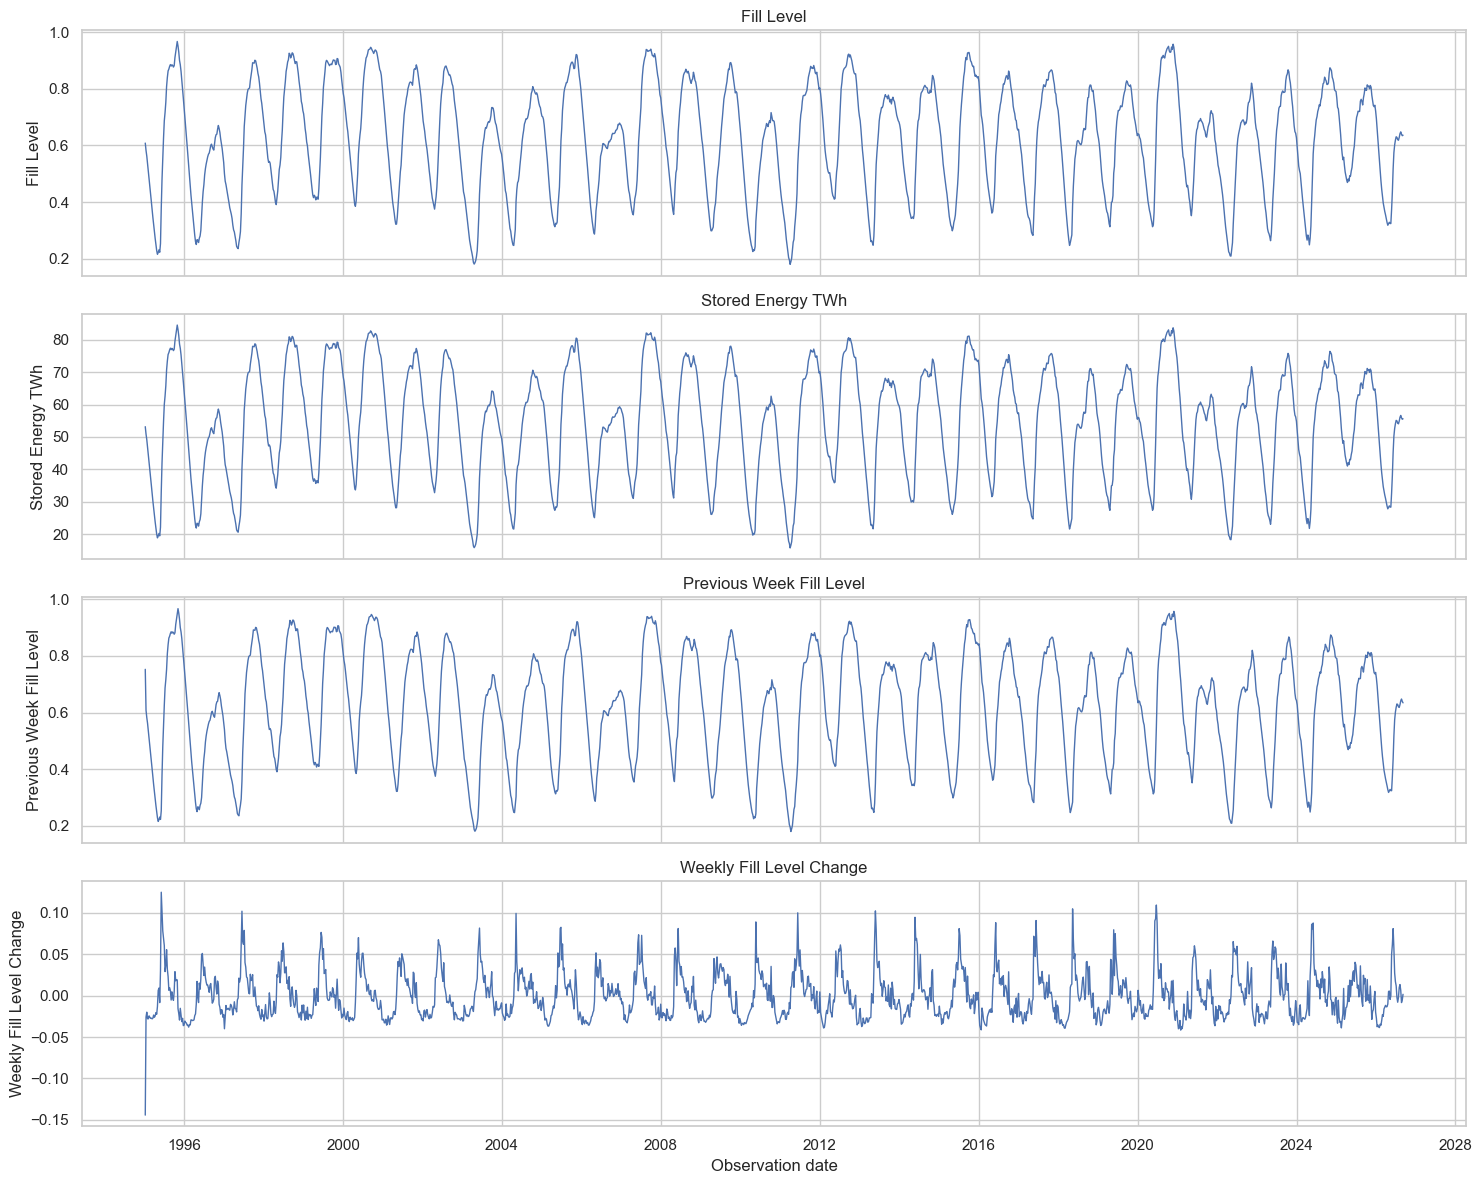

In [3]:
# Keep one area throughout, so each line has one value per observation date.
national = df.loc[(df["Area Type"] == "NO") & (df["Area Code"] == 0)].copy()
national = national.sort_values("Observation Date")
measurement_columns = [
    "Fill Level",
    "Stored Energy TWh",
    "Previous Week Fill Level",
    "Weekly Fill Level Change",
]

# Plot each original measurement on its own axis, without standardising it.
fig, axes = plt.subplots(len(measurement_columns), 1, figsize=(15, 12), sharex=True)
for ax, column in zip(axes, measurement_columns):
    sns.lineplot(
        data=national, x="Observation Date", y=column,
        estimator=None, errorbar=None, linewidth=1, ax=ax,
    )
    ax.set_title(column)
    ax.set_xlabel("")
axes[-1].set_xlabel("Observation date")
fig.tight_layout()
plt.show()

## The same time series together on a standardised scale

This plot combines the same four national measurements shown separately above. Each series is standardised to its own z-scores before plotting, so the different original units do not dominate the comparison. Zero is that measurement's mean; one is one standard deviation above it. Fill level and stored energy nearly overlap because national capacity is fixed.

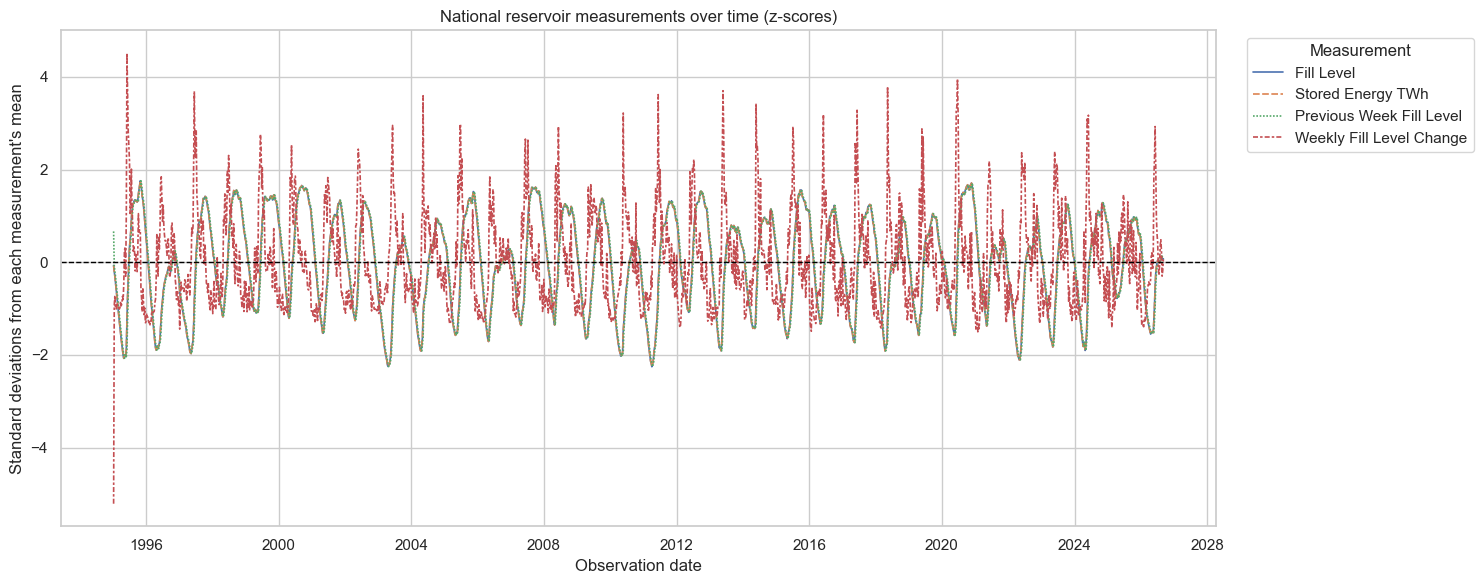

In [4]:
# Reuse the four series above, standardising each across its own dates.
standardised = (
    national[measurement_columns] - national[measurement_columns].mean()
) / national[measurement_columns].std()
standardised["Observation Date"] = national["Observation Date"].to_numpy()
comparison_data = standardised.melt(
    id_vars="Observation Date", var_name="Measurement", value_name="Z-score"
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(
    data=comparison_data, x="Observation Date", y="Z-score",
    hue="Measurement", style="Measurement",
    estimator=None, errorbar=None, linewidth=1.2, ax=ax,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("National reservoir measurements over time (z-scores)")
ax.set_xlabel("Observation date")
ax.set_ylabel("Standard deviations from each measurement's mean")
ax.legend(title="Measurement", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## Compulsory work log

I used this notebook as the main development and documentation workspace for the Norwegian reservoir dataset. It reads the local `reservoirs.csv` file, replaces abbreviated Norwegian headers with readable English names, and parses the observation and next-publication dates. Checking the source columns exposed an early mapping error: Stored Energy TWh had been omitted, which shifted the later names. I corrected the mapping against the CSV before continuing with the analysis.

Because the reservoir data is recorded weekly, I replaced the distribution and box plots with time-series charts. I chose the national series, NO 0, so every measurement refers to the same area and dates. The first figure gives fill level, stored energy, previous-week fill level, and weekly fill-level change a separate line plot each, preserving their original units and making their individual patterns easier to see. The second figure puts those exact four time series together. I standardised each measurement to its own z-scores first, so differences in units and scale do not dominate the combined plot. ISO year and week describe the time axis rather than measured quantities, while national capacity is constant and cannot be usefully standardised. The notebook keeps the code, outputs, and explanations together so the analysis can be rerun locally.

I built a four-page Streamlit counterpart from the same CSV. Its home page summarizes the data; the data page shows a first-month line chart for each of nine weekly area series alongside the source records; the plot page lets a viewer choose one series or all nine and select a month range; and the about page explains the area codes. Unlike the notebook's broad exploration, the dashboard plots only numeric fill-level values. The app reshapes those values from long-form source rows into one column per area series, converts them to percentages, and caches the processed data so page reruns do not repeat the CSV work. The interactive plot uses Seaborn, matching the notebook's plotting library, with Matplotlib handling its figure and date-axis formatting.

Working across both environments clarified why the notebook is useful for inspecting and explaining every source field, while Streamlit is better for a focused interactive view. I ran the notebook code cells and checked the four app pages locally, including the area and month controls. The notebook and app code are in the [public GitHub repository](https://github.com/dared22/ind320), and the dashboard is available as a [deployed Streamlit app](https://cklqlkatpe9mqyrnuch2ma.streamlit.app/About).

## AI-tool use

I used AI to help improve the column names and notebook presentation, identify and correct the shifted column mapping, draft and test the plotting code, and implement and check the Streamlit pages and cached data loader. It also helped update the Python dependencies and this documentation. I checked suggestions against the CSV, executed the notebook cells, and tested the app locally. I remain responsible for the analysis, wording, and final submission.